# Distillation Test-Set Heatmap

Per (teacher × student × condition) cell, computes the mean binary harm F1 across the 5 OOD test datasets (`wildguardmix`, `xstest`, `toxic-chat`, `aegis`, `openai-moderation`) and renders a 3-panel heatmap mirroring the OOD-val figure in `distillation_results.ipynb`. The in-distribution dataset (`annotated-intents`) is loaded as a sanity column but excluded from the headline mean.

Data source: `data/safety_experiment/distillation/{teacher}/{student}/{condition}/{dataset}/*.jsonl`, produced by `submit_distillation_eval.py --mode test-all`. Each JSONL row contains `predicted_harm` and `true_harm_binary` — same schema used by `compute_binary_metrics` in `distillation_results.ipynb`.

In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "CLAUDE.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / "data" / "safety_experiment" / "distillation"
FIGURES_DIR  = PROJECT_ROOT / "notebooks" / "distillation" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Results root: {RESULTS_ROOT}")

Results root: /scratch/s4626451/intention-jailbreak/data/safety_experiment/distillation


In [18]:
# Same canonical labels and ordering as distillation_results.ipynb.
TEACHERS = {
    "cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit": "Mistral 4 119B",
    "Qwen-Qwen3-32B":                              "Qwen 3 32B",
    "openai-gpt-oss-120b":                         "GPT-OSS 120B",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16":     "Gemma 3 27B",
}
STUDENTS = {
    "gemma-3-12b":              "Gemma 3 12B",
    "llama-3.1-8b":             "Llama 3.1 8B",
    # Ministral 3 14B excluded: training never converged (~70% empty val outputs)
    # due to Mistral V7 chat template having no assistant-turn opener for SFT to anchor on.
    "qwen3-8b":                 "Qwen 3 8B",
}
CONDITIONS = {
    "no_intent":        "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent":     "Human Intent",
}
OOD_TEST_DATASETS = {
    "wildguardmix":      "WildGuardMix",
    "xstest":            "XSTest",
    "toxic-chat":        "Toxic Chat",
    "aegis":             "Aegis",
    "openai-moderation": "OpenAI Moderation",
}
IN_DIST_DATASET = ("annotated-intents", "Annotated Intents")

TEACHER_SLUG_ORDER   = list(TEACHERS.keys())
STUDENT_SLUG_ORDER   = list(STUDENTS.keys())
CONDITION_SLUG_ORDER = list(CONDITIONS.keys())
TEACHER_ORDER   = list(TEACHERS.values())
STUDENT_ORDER   = list(STUDENTS.values())
CONDITION_ORDER = list(CONDITIONS.values())

In [19]:
def _to_binary_label(value):
    if value is None:
        return None
    text = str(value).strip().lower()
    if text in {"harmful", "unsafe", "1", "true", "yes"}:
        return 1
    if text in {"safe", "unharmful", "0", "false", "no"}:
        return 0
    return None


def compute_jsonl_metrics(jsonl_path: Path) -> dict | None:
    y_true, y_pred = [], []
    n_total = n_parse_fail = 0
    with jsonl_path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            n_total += 1
            rec = json.loads(line)
            t = _to_binary_label(rec.get("true_harm_binary") or rec.get("true_harm"))
            p = _to_binary_label(rec.get("predicted_harm"))
            if t is None:
                continue
            if p is None:
                n_parse_fail += 1
                p = 0  # parse failure → "safe" (matches distillation_results.ipynb policy)
            y_true.append(t)
            y_pred.append(p)
    if not y_true:
        return None
    return {
        "f1":              f1_score(y_true, y_pred, zero_division=0),
        "precision":       precision_score(y_true, y_pred, zero_division=0),
        "recall":          recall_score(y_true, y_pred, zero_division=0),
        "n":               len(y_true),
        "n_total":         n_total,
        "n_parse_fail":    n_parse_fail,
    }


def find_jsonl(dataset_dir: Path) -> Path | None:
    if not dataset_dir.exists():
        return None
    preferred = sorted(dataset_dir.glob("*_classification.jsonl")) + \
                sorted(dataset_dir.glob("*_human_intent.jsonl")) + \
                sorted(dataset_dir.glob("*_synthetic_intent.jsonl"))
    if preferred:
        return preferred[0]
    any_jsonl = sorted(dataset_dir.glob("*.jsonl"))
    return any_jsonl[0] if any_jsonl else None

In [20]:
all_datasets = {**OOD_TEST_DATASETS, IN_DIST_DATASET[0]: IN_DIST_DATASET[1]}

rows = []
for t_slug in TEACHER_SLUG_ORDER:
    for s_slug in STUDENT_SLUG_ORDER:
        for c_slug in CONDITION_SLUG_ORDER:
            combo_dir = RESULTS_ROOT / t_slug / s_slug / c_slug
            if not combo_dir.exists():
                continue
            for ds_slug, ds_name in all_datasets.items():
                ds_dir = combo_dir / ds_slug
                jsonl  = find_jsonl(ds_dir)
                if jsonl is None:
                    continue
                m = compute_jsonl_metrics(jsonl)
                if m is None:
                    continue
                rows.append({
                    "teacher_slug":   t_slug,
                    "teacher":        TEACHERS[t_slug],
                    "student_slug":   s_slug,
                    "student":        STUDENTS[s_slug],
                    "condition_slug": c_slug,
                    "condition":      CONDITIONS[c_slug],
                    "dataset_slug":   ds_slug,
                    "dataset":        ds_name,
                    "is_ood":         ds_slug in OOD_TEST_DATASETS,
                    **m,
                })

df = pd.DataFrame(rows)
for col, order in [("teacher", TEACHER_ORDER), ("student", STUDENT_ORDER), ("condition", CONDITION_ORDER)]:
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)
df = df.sort_values(["teacher", "student", "condition", "dataset"]).reset_index(drop=True)

n_combos_seen = df.groupby(["teacher", "student", "condition"], observed=True).ngroups
expected_combos = len(TEACHERS) * len(STUDENTS) * len(CONDITIONS)
print(f"Combos with at least one dataset: {n_combos_seen} / {expected_combos}")
print(f"Total dataset evaluations loaded: {len(df)}")
df.head()

Combos with at least one dataset: 36 / 36
Total dataset evaluations loaded: 216


,teacher_slug,teacher,student_slug,student,condition_slug,condition,dataset_slug,dataset,is_ood,f1,precision,recall,n,n_total,n_parse_fail
0,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,aegis,Aegis,True,0.824828,0.803763,0.847025,1964,1964,0
1,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,annotated-intents,Annotated Intents,False,0.771084,0.780488,0.761905,173,173,0
2,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,openai-moderation,OpenAI Moderation,True,0.769106,0.668079,0.906130,1680,1680,0
3,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,toxic-chat,Toxic Chat,True,0.665936,0.551724,0.839779,5083,5083,1
4,cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit,Mistral 4 119B,gemma-3-12b,Gemma 3 12B,no_intent,No Intent,wildguardmix,WildGuardMix,True,0.859740,0.842239,0.877984,1699,1699,0


In [21]:
# Per-combo OOD mean F1 — the headline number for the heatmap.
ood_only = df[df["is_ood"]].copy()
missing_datasets = (
    ood_only.groupby(["teacher", "student", "condition"], observed=True)["dataset_slug"]
    .nunique()
    .reset_index(name="n_ood_datasets")
)
incomplete = missing_datasets[missing_datasets["n_ood_datasets"] < len(OOD_TEST_DATASETS)]
if not incomplete.empty:
    print(f"[warn] {len(incomplete)} combo(s) missing one or more OOD datasets — F1 is averaged over what loaded:")
    for _, row in incomplete.iterrows():
        print(f"  - {row['teacher']} / {row['student']} / {row['condition']}: {int(row['n_ood_datasets'])}/{len(OOD_TEST_DATASETS)} datasets")

combo_mean = (
    ood_only.groupby(["teacher", "student", "condition"], as_index=False, observed=True)
    .agg(mean_f1=("f1", "mean"),
         min_f1=("f1", "min"),
         max_f1=("f1", "max"),
         n_datasets=("dataset_slug", "nunique"))
)
combo_mean.round(4)

,teacher,student,condition,mean_f1,min_f1,max_f1,n_datasets
0,Mistral 4 119B,Gemma 3 12B,No Intent,0.8057,0.6659,0.9091,5
1,Mistral 4 119B,Gemma 3 12B,Synthetic Intent,0.7905,0.6695,0.8959,5
2,Mistral 4 119B,Gemma 3 12B,Human Intent,0.8008,0.7007,0.9021,5
3,Mistral 4 119B,Llama 3.1 8B,No Intent,0.7789,0.6368,0.8596,5
4,Mistral 4 119B,Llama 3.1 8B,Synthetic Intent,0.7879,0.6615,0.8744,5
5,Mistral 4 119B,Llama 3.1 8B,Human Intent,0.8016,0.6938,0.8914,5
6,Mistral 4 119B,Qwen 3 8B,No Intent,0.7848,0.6715,0.8775,5
7,Mistral 4 119B,Qwen 3 8B,Synthetic Intent,0.7951,0.7089,0.8667,5
8,Mistral 4 119B,Qwen 3 8B,Human Intent,0.7967,0.7016,0.8713,5
9,Qwen 3 32B,Gemma 3 12B,No Intent,0.7930,0.6262,0.9163,5


In [22]:
# Per (teacher × student × condition × dataset) F1 table — useful for spot checks.
pivot_per_ds = (
    df.pivot_table(
        index=["teacher", "student", "condition"],
        columns="dataset",
        values="f1",
        observed=True,
    )
    .round(4)
)
pivot_per_ds

dataset                                        Aegis  Annotated Intents  \
teacher        student      condition                                     
Mistral 4 119B Gemma 3 12B  No Intent         0.8248             0.7711   
                            Synthetic Intent  0.8239             0.7182   
                            Human Intent      0.8119             0.7263   
               Llama 3.1 8B No Intent         0.8306             0.7219   
                            Synthetic Intent  0.8234             0.7125   
                            Human Intent      0.8188             0.6099   
               Qwen 3 8B    No Intent         0.8306             0.6939   
                            Synthetic Intent  0.8202             0.6623   
                            Human Intent      0.8006             0.6571   
Qwen 3 32B     Gemma 3 12B  No Intent         0.8316             0.7571   
                            Synthetic Intent  0.8176             0.7528   
                            Human Intent      0.8105             0.7059   
               Llama 3.1 8B No Intent         0.8281             0.6429   
                            Synthetic Intent  0.8240             0.6842   
                            Human Intent      0.7965             0.6832   
               Qwen 3 8B    No Intent         0.8240             0.6447   
                            Synthetic Intent  0.8192             0.6259   
                            Human Intent      0.8147             0.6069   
GPT-OSS 120B   Gemma 3 12B  No Intent         0.8199             0.7527   
                            Synthetic Intent  0.8134             0.7456   
                            Human Intent      0.8055             0.7574   
               Llama 3.1 8B No Intent         0.8330             0.6750   
                            Synthetic Intent  0.8111             0.6667   
                            Human Intent      0.8107             0.7439   
               Qwen 3 8B    No Intent         0.8359             0.6957   
                            Synthetic Intent  0.8079             0.6575   
                            Human Intent      0.7910             0.6423   
Gemma 3 27B    Gemma 3 12B  No Intent         0.8109             0.7513   
                            Synthetic Intent  0.7988             0.7447   
                            Human Intent      0.8053             0.7333   
               Llama 3.1 8B No Intent         0.8239             0.7200   
                            Synthetic Intent  0.8109             0.7066   
                            Human Intent      0.8202             0.7683   
               Qwen 3 8B    No Intent         0.8071             0.7229   
                            Synthetic Intent  0.8171             0.7239   
                            Human Intent      0.8109             0.7226   

dataset                                       OpenAI Moderation  Toxic Chat  \
teacher        student      condition                                         
Mistral 4 119B Gemma 3 12B  No Intent                    0.7691      0.6659   
                            Synthetic Intent             0.7313      0.6695   
                            Human Intent                 0.7445      0.7007   
               Llama 3.1 8B No Intent                    0.7291      0.6368   
                            Synthetic Intent             0.7463      0.6615   
                            Human Intent                 0.7573      0.6938   
               Qwen 3 8B    No Intent                    0.7234      0.6715   
                            Synthetic Intent             0.7557      0.7089   
                            Human Intent                 0.7635      0.7016   
Qwen 3 32B     Gemma 3 12B  No Intent                    0.7416      0.6262   
                            Synthetic Intent             0.7549      0.6329   
                            Human Intent                 0.7731      0.6638   
               Llama 3.1 8B No Intent      

## Test-set heatmap (mean F1 across 5 OOD datasets)

Same layout as the OOD-validation heatmap in `distillation_results.ipynb`: 1×3 panels, one per condition, teachers on rows, students on columns, shared colour scale. The cell with the highest F1 per (teacher, student) row gets a **gold border** so the winning condition is easy to spot.

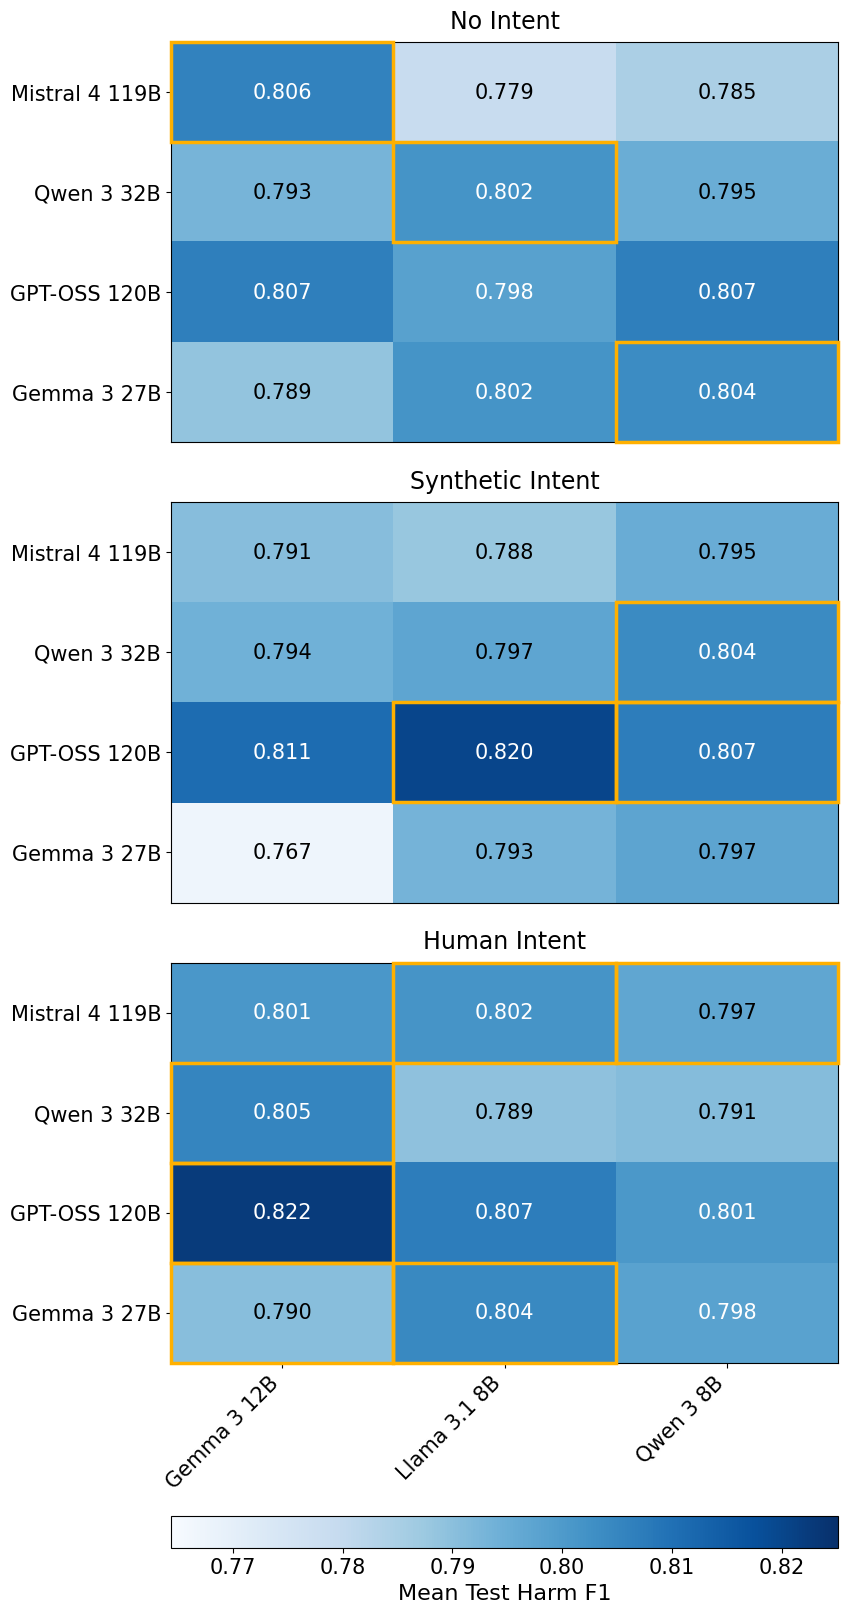

In [30]:
# 3×1 panels, one per condition. Cells show absolute F1 across all 3 panels with a
# tight colour range. For each (teacher, student) row, the condition with the highest
# F1 gets a gold border so the winning condition pops out at a glance.
from matplotlib.transforms import Bbox

n_panels = len(CONDITION_SLUG_ORDER)
n_rows = len(TEACHER_ORDER)
n_cols = len(STUDENT_ORDER)

fig_w = 1.8 * n_cols + 3.5
fig_h = 1.05 * n_rows * n_panels + 3.5

CELL_FONTSIZE  = 15
TITLE_FONTSIZE = 17
TICK_FONTSIZE  = 15
LABEL_FONTSIZE = 16

# Build the three pivots and stack into a (n_panels, n_rows, n_cols) array so we can
# easily find the winning condition per (teacher, student).
pivots = {}
for c_slug in CONDITION_SLUG_ORDER:
    c_name = CONDITIONS[c_slug]
    pivots[c_slug] = (
        combo_mean[combo_mean["condition"] == c_name]
        .pivot(index="teacher", columns="student", values="mean_f1")
        .reindex(index=TEACHER_ORDER, columns=STUDENT_ORDER)
    )

stack = np.stack([pivots[c].values for c in CONDITION_SLUG_ORDER], axis=0)  # (3, R, C)
# argmax over the condition axis, ignoring NaNs
winner_idx = np.nanargmax(np.where(np.isnan(stack), -np.inf, stack), axis=0)

# Tight colour range covering only the realised data so variation is visible.
data_min = float(np.nanmin(stack))
data_max = float(np.nanmax(stack))
# Pad slightly so values don't sit at the exact edges of the cmap.
pad = (data_max - data_min) * 0.05
vmin = data_min - pad
vmax = data_max + pad
cmap = plt.get_cmap("Blues")

fig, axes = plt.subplots(n_panels, 1, figsize=(fig_w, fig_h), sharex=True)
if n_panels == 1:
    axes = [axes]
for ax in axes[:-1]:
    ax.xaxis.set_visible(False)

WINNER_COLOR = "#FFB000"   # warm gold — visible across the full Blues range
WINNER_LW    = 2.5

for panel_idx, (ax, c_slug) in enumerate(zip(axes, CONDITION_SLUG_ORDER)):
    pivot = pivots[c_slug]
    image = ax.imshow(pivot.values, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
    ax.set_title(CONDITIONS[c_slug], pad=10, fontsize=TITLE_FONTSIZE)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns,
                  rotation=45, ha="right", fontsize=TICK_FONTSIZE)
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index, fontsize=TICK_FONTSIZE)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            if pd.isna(cell_value):
                ax.text(j, i, "—", ha="center", va="center", color="#888", fontsize=CELL_FONTSIZE)
                continue
            norm = (cell_value - vmin) / (vmax - vmin + 1e-12)
            text_color = "white" if norm > 0.55 else "black"
            ax.text(j, i, f"{cell_value:.3f}", ha="center", va="center",
                    color=text_color, fontsize=CELL_FONTSIZE)
            # Gold border around the winning condition for this (teacher, student) row.
            if winner_idx[i, j] == panel_idx:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                           fill=False, edgecolor=WINNER_COLOR,
                                           linewidth=WINNER_LW, zorder=5,
                                           clip_on=False))

fig.subplots_adjust(hspace=0.15, left=0.22, right=0.97, bottom=0.13, top=0.95)
_p_bottom = axes[-1].get_position()
# Span the full width of the heatmap cells so the colorbar reads as a labeled axis
# directly under the data, not a free-floating element.
cbar_ax = fig.add_axes([_p_bottom.x0, 0.015, _p_bottom.x1 - _p_bottom.x0, 0.02])
cbar = fig.colorbar(image, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Mean Test Harm F1", fontsize=LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

# Symmetric save bbox: pad the right side so the cell axes (and colorbar, which spans
# the same width) sit at the horizontal centre of the saved PDF. Without this the
# y-tick labels protrude to the left, so a LaTeX caption underneath looks off-centre
# relative to the heatmap.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
tight_bbox = fig.get_tightbbox(renderer)  # inches
ax_disp = axes[-1].get_window_extent(renderer)
inv = fig.dpi_scale_trans.inverted()
ax_x0_in, _ = inv.transform((ax_disp.x0, 0))
ax_x1_in, _ = inv.transform((ax_disp.x1, 0))
cell_cx = (ax_x0_in + ax_x1_in) / 2
half_w = max(cell_cx - tight_bbox.x0, tight_bbox.x1 - cell_cx)
sym_bbox = Bbox.from_extents(cell_cx - half_w, tight_bbox.y0,
                             cell_cx + half_w, tight_bbox.y1)

fig.savefig(FIGURES_DIR / "distillation_test_heatmap.pdf", bbox_inches=sym_bbox)
plt.show()


In [24]:
# Summary stats on the headline mean-OOD-F1 numbers.
print("Mean OOD F1 across the test-set heatmap cells:")
combo_mean["mean_f1"].describe().round(4)

Mean OOD F1 across the test-set heatmap cells:


count    36.0000
mean      0.7982
std       0.0105
min       0.7671
25%       0.7924
50%       0.7981
75%       0.8045
max       0.8224
Name: mean_f1, dtype: float64